# TinyTroupe Demo: Gen Z Skincare Concept Test

This notebook runs a small **virtual concept test** for a Gen Z (US, ages 18–28) skincare product, using [TinyTroupe](https://github.com/microsoft/TinyTroupe) — Microsoft's framework for multi-agent LLM-driven persona simulation.

## What it does

1. **Generates** 10 Gen Z US personas from `usa.json` demographics via `TinyPersonFactory`.
2. **Runs** a one-question concept test (three skincare concepts, one preferred choice + explanation per persona).
3. **Extracts** structured results (preferred option, reasoning, purchase likelihood, improvement) and saves them to `result.csv`.
4. **Compares** the result against a parallel run using a different engine (see [claude-persona genz-skincare demo](https://github.com/takechanman1228/claude-persona/tree/main/demo/genz-skincare)).

## Concepts under test

- **A — Acne Control Serum**: fights breakouts with clinically proven actives
- **B — Barrier Repair Cream**: strengthens skin barrier and reduces redness
- **C — Glow Boosting Toner**: brightens dull skin and supports a more even complexion

Default model: `gpt-5-mini` (the TinyTroupe 0.7.0 default; configured in `config.ini`).


In [1]:
import os
# Set OPENAI_API_KEY in your shell BEFORE launching Jupyter (e.g. `export OPENAI_API_KEY=sk-...`).
assert os.environ.get("OPENAI_API_KEY"), "Please set OPENAI_API_KEY in your shell before running this notebook."


In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from tinytroupe.agent import TinyPerson
from tinytroupe.environment import TinyWorld
from tinytroupe.factory import TinyPersonFactory
from tinytroupe.extraction import ResultsExtractor
import tinytroupe.control as control

extractor = ResultsExtractor()



!!!!
DISCLAIMER: TinyTroupe relies on Artificial Intelligence (AI) models to generate content. 
The AI models are not perfect and may produce inappropriate or inaccurate results. 
For any serious or consequential use, please review the generated content before using it.
!!!!

Looking for default config on: /Users/take/Develop/TinyTroupe/TinyTroupe/tinytroupe/utils/../config.ini
Found custom config on: /Users/take/Develop/TinyTroupe/effective-persona-simulation/demos/genz-skincare/config.ini
TinyTroupe version: 0.7.0
Current date and time (local): 2026-04-23 00:49:44
Current date and time (UTC):   2026-04-23 04:49:44

Current TinyTroupe configuration 
[OpenAI]
api_type = openai
azure_api_version = 2024-08-01-preview
model = gpt-5-mini
reasoning_model = o3-mini
vision_detail = auto
embedding_model = text-embedding-3-small
azure_embedding_model_api_version = 2023-05-15
max_completion_tokens = 128000
timeout = 480
max_attempts = 5
waiting_time = 0
exponential_backoff_factor = 5
max_concur

In [3]:
control.begin('cache.json')


2026-04-23 00:49:46,769 - MainThread(8757062720) - tinytroupe - INFO - Cache file not found on path: cache.json.


## 1. Generate the persona panel

Synthesize 10 Gen Z (ages 18–28) US personas from `usa.json` demographics using TinyTroupe's `TinyPersonFactory` (the Microsoft factory idiom). First run takes ~1–2 minutes; reruns hit the simulation cache (`cache.json`) and are near-instant.


In [4]:
TinyPerson.clear_agents()

factory = TinyPersonFactory.create_factory_from_demography(
    "./usa.json",
    population_size=10,
    additional_demographic_specification="Gen Z skincare shoppers in the US (ages 18-28).",
)
panel = factory.generate_people(10, temperature=1.3)

print(f"✅ Generated {len(panel)} personas")
for a in panel:
    occ = a.get("occupation")
    occ_title = occ.get("title") if isinstance(occ, dict) else occ
    print(f"  - {a.get('name')} | age {a.get('age')} | {occ_title}")

import os
os.makedirs("exported_personas", exist_ok=True)
for a in panel:
    a.save_specification(
        f"exported_personas/{a.get('name').replace(' ', '_')}.json",
        include_memory=False,
    )
print(f"Saved {len(panel)} persona specs to exported_personas/")


2026-04-23 00:51:33,718 - ThreadPoolExecutor-1_0(6267367424) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 00:51:33,735 - ThreadPoolExecutor-1_0(6267367424) - tinytroupe - INFO - Sampling dimensions computed successfully.


2026-04-23 00:53:24,004 - ThreadPoolExecutor-1_0(6267367424) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 00:53:24,183 - ThreadPoolExecutor-1_0(6267367424) - tinytroupe - INFO - Sampling plan computed successfully.


2026-04-23 00:53:24,187 - ThreadPoolExecutor-1_0(6267367424) - tinytroupe - INFO - Sample plan has been flattened, contains 10 total samples.


...

2026-04-23 01:00:48,612 - ThreadPoolExecutor-1_4(6334672896) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:01:06,247 - ThreadPoolExecutor-1_8(6401978368) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:01:22,729 - ThreadPoolExecutor-1_6(6368325632) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:01:44,235 - ThreadPoolExecutor-1_7(6385152000) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


✅ Generated 10 personas
  - Ethan Cole Miller | age 25 | Automotive Service Technician (entry to mid-level)
  - Valentina Marisol Vega | age 24 | Part-time Retail Beauty Specialist and Brand Ambassador; Freelance Micro-Influencer (skincare-focused)
  - Caleb Preston Lane | age 27 | Freelance Content Creator / Skincare & Lifestyle Creator
  - Kai Nguyen | age 22 | Full-time undergraduate student; part-time barista/shift lead
  - Aaliyah Simone Thompson | age 20 | Full-time college student; Part-time sales associate
  - Mateo Javier Navarro | age 27 | Medical Assistant (Dermatology Clinic)
  - Harper Elise Whitman | age 25 | Freelance Social Media Creator & Consultant (beauty/skincare); Part-time Community Manager for boutique PR/beauty agency
  - Ari Lin Bennett | age 22 | Pharmacy Technician (part-time); occasional gig worker (delivery and on-demand retail shifts)
  - Maya Celeste Park-Garcia | age 20 | Full-time Undergraduate Student
  - Savannah Rae Carter | age 23 | Part-time front-

## 2. Discovery: open-ended question

Before showing concepts, ask one open-ended question to surface unprompted pain points. This mirrors the [claude-persona ask step](https://github.com/takechanman1228/claude-persona/tree/main/demo/genz-skincare) so the two engines can be compared on identical questions.

> *"When you're choosing which skincare products to buy, what frustrates you the most?"*

Each persona answers in their own voice; we extract a short answer, the underlying reasoning, themes, and a single emotion tag. Personas keep memory across discovery → concept test (one continuous interview), just like a real consumer interview flow.


In [5]:
%%time
DISCOVERY_QUESTION = (
    "When you're choosing which skincare products to buy, what frustrates you the most? "
    "Please share in your own words — the biggest pain point, annoyance, or thing that makes the process hard."
)

run_ts_d = datetime.now().strftime("%Y%m%d_%H%M%S")
for i, agent in enumerate(panel, start=1):
    print(f"[{i}/{len(panel)}] Asking: {agent.get('name')}...")
    world = TinyWorld(f"Discovery_Room_{run_ts_d}_{i}", [agent])
    world.broadcast("I'd like to ask you a quick open question about how you shop for skincare.")
    world.broadcast(DISCOVERY_QUESTION)
    world.run(1)
    print(f"    ✓ done")


[1/10] Asking: Ethan Cole Miller...


USER --> Ethan Cole Miller: [CONVERSATION] 
          > I'd like to ask you a quick open question about how you shop for skincare.

USER --> Ethan Cole Miller: [CONVERSATION] 
          > When you're choosing which skincare products to buy, what frustrates you the most?
          > Please share in your own words — the biggest pain point, annoyance, or thing that makes
          > the process hard.

2026-04-23 01:01:44,313 - MainThread(8757062720) - tinytroupe - INFO - [Discovery_Room_20260423_010144_1] Running world simulation step 1 of 1.


────────────────────────────────── Discovery_Room_20260423_010144_1 step 1 of 1 ───────────────────────────────────

...

2026-04-23 01:07:07,724 - ThreadPoolExecutor-11_0(6267367424) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Savannah Rae Carter acts: [THINK] 
                         > Alright — I need to answer plainly and in my own voice. Mention the
                         > practical stuff: cost and wasting money, confusing labels/marketing,
                         > fragrance and irritation, changing formulas, lack of samples/trial sizes
                         > in-store, and complicated multi-step routines that feel unrealistic on a
                         > budget. Also note that I check price-per-ounce and wait for sales. Keep
                         > it short, soft-spoken, and honest.

Savannah Rae Carter acts: [TALK] 
                         > Honestly, the biggest thing that frustrates me is the fear of wasting
                         > money. I don't want to buy something full-price only to find it irritates
                         > my skin or does nothing. A few other annoyances: unclear or hype-y
                         > labeling that makes it hard to tell what the product actually does;
                         > formulas that change so a favorite disappears; strong fragrances that
                         > make my skin sting; no easy way to try things in store (samples or travel
                         > sizes) so you feel like you're guessing; and routines that demand a dozen
                         > steps — that's not realistic with my schedule or budget. I also check
                         > price-per-ounce and wait for sales, so when stores don't stock something
                         > regularly or it’s never on sale, that makes it harder. In short: I want
                         > simple, gentle, affordable stuff that I can test without risking a whole
                         > bottle.

Savannah Rae Carter acts: [DONE] 
                         > Waiting for any follow-up questions.

    ✓ done
CPU times: user 1.41 s, sys: 292 ms, total: 1.71 s
Wall time: 5min 23s


In [6]:
def extract_discovery_results(panel):
    rows = []
    for agent in panel:
        extraction = extractor.extract_results_from_agent(
            agent,
            extraction_objective=(
                "Extract the persona's frustration with shopping for skincare. Capture their main "
                "pain point, the underlying reasoning, 3-4 keyword themes, and the dominant emotion."
            ),
            situation=(
                "Open-ended discovery question: 'When you're choosing skincare products, what "
                "frustrates you the most?'"
            ),
            fields=["short_answer", "reasoning", "themes", "emotion"],
        )
        if extraction is None:
            continue
        occ = agent.get("occupation")
        occ_title = occ.get("title") if isinstance(occ, dict) else occ
        rows.append({
            "name": agent.get("name"),
            "age": agent.get("age"),
            "occupation": occ_title,
            "short_answer": extraction.get("short_answer"),
            "reasoning": extraction.get("reasoning"),
            "themes": extraction.get("themes"),
            "emotion": extraction.get("emotion"),
        })
    return pd.DataFrame(rows)

discovery_df = extract_discovery_results(panel)
discovery_df.to_csv("discovery.csv", index=False)
display(discovery_df[["name", "age", "occupation", "short_answer", "emotion", "themes"]])


2026-04-23 01:07:18,593 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:07:30,512 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:07:39,478 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:07:54,112 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:08:09,025 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-04-23 01:08:35,607 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:08:47,462 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:08:58,932 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:09:12,250 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


,name,age,occupation,short_answer,emotion,themes
0,Ethan Cole Miller,25,Automotive Service Technician (entry to mid-le...,Not being able to tell if a product actually w...,frustration,"[marketing/hype, greasy/white-cast, confusing ..."
1,Valentina Marisol Vega,24,Part-time Retail Beauty Specialist and Brand A...,Vague ingredient claims and no way to try prod...,frustration,"[ingredient transparency, no sampling/try-befo..."
2,Caleb Preston Lane,27,Freelance Content Creator / Skincare & Lifesty...,The biggest frustration is the lack of real tr...,frustration,"[Transparency (concentrations/pH), Greenwashin..."
3,Kai Nguyen,22,Full-time undergraduate student; part-time bar...,The biggest frustration is a lack of transpare...,frustration,"[hidden/unclear fragrance, ingredient transpar..."
4,Aaliyah Simone Thompson,20,Full-time college student; Part-time sales ass...,Opaque marketing and hype combined with high p...,frustration,"[opaque marketing, price / financial risk, irr..."
5,Mateo Javier Navarro,27,Medical Assistant (Dermatology Clinic),Lack of transparency — brands hide active ingr...,frustration,"[transparency, ingredient concentrations, dive..."
6,Harper Elise Whitman,25,Freelance Social Media Creator & Consultant (b...,Opaque marketing and missing ingredient/concen...,frustration,"[ingredient transparency, misleading/performat..."
7,Ari Lin Bennett,22,Pharmacy Technician (part-time); occasional gi...,Poor transparency — vague labeling and missing...,frustration,"[Transparency, Ingredient disclosure (INCI/pre..."
8,Maya Celeste Park-Garcia,20,Full-time Undergraduate Student,The biggest frustration is a lack of transpare...,frustration,"[transparency (concentration & pH), misleading..."
9,Savannah Rae Carter,23,Part-time front-end retail associate / OTC sto...,Fear of wasting money on skincare that irritat...,frustration/anxiety,"[cost/waste, confusing marketing/labels, no sa..."


## 3. Run the concept test

Each persona reacts to all three concepts in an isolated `TinyWorld` and is asked to pick one, justify the choice, rate purchase likelihood, and suggest one improvement.


In [7]:
%%time
CONCEPTS = """
**Option A: Acne Control Serum** — fights breakouts with clinically proven actives.

**Option B: Barrier Repair Cream** — strengthens skin barrier and reduces redness.

**Option C: Glow Boosting Toner** — brightens dull skin and supports a more even complexion.
"""

run_ts = datetime.now().strftime("%Y%m%d_%H%M%S")

for i, agent in enumerate(panel, start=1):
    print(f"[{i}/{len(panel)}] Interviewing: {agent.get('name')}...")
    world = TinyWorld(f"ConceptTest_Room_{run_ts}_{i}", [agent])
    world.broadcast("Welcome. I'd like your reaction to three new skincare product concepts we're developing.")
    world.broadcast(
        f"Here are the three concepts:\n{CONCEPTS}\n\n"
        "Which ONE (A, B, or C) is your top choice? Please explain why, how likely you'd actually be to buy it, "
        "and what one thing you'd change about it to make it better."
    )
    world.run(1)
    print(f"    ✓ done")


[1/10] Interviewing: Ethan Cole Miller...


USER --> Ethan Cole Miller: [CONVERSATION] 
          > Welcome. I'd like your reaction to three new skincare product concepts we're developing.

USER --> Ethan Cole Miller: [CONVERSATION] 
          > Here are the three concepts:  **Option A: Acne Control Serum** — fights breakouts with
          > clinically proven actives.  **Option B: Barrier Repair Cream** — strengthens skin
          > barrier and reduces redness.  **Option C: Glow Boosting Toner** — brightens dull skin
          > and supports a more even complexion.   Which ONE (A, B, or C) is your top choice? Please
          > explain why, how likely you'd actually be to buy it, and what one thing you'd change
          > about it to make it better.

2026-04-23 01:09:12,353 - MainThread(8757062720) - tinytroupe - INFO - [ConceptTest_Room_20260423_010912_1] Running world simulation step 1 of 1.


───────────────────────────────── ConceptTest_Room_20260423_010912_1 step 1 of 1 ──────────────────────────────────

...

2026-04-23 01:14:39,315 - ThreadPoolExecutor-21_0(6382727168) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Savannah Rae Carter acts: [THINK] 
                         > Okay — think about what would actually matter to me and customers like
                         > me. My biggest concerns are dry, sensitive skin and not wanting to waste
                         > money. A product that strengthens the skin barrier and reduces redness
                         > sounds practical and useful year-round, especially in winter. I should
                         > pick the option that feels simple, gentle, and multi-use. Also remember
                         > to mention buy-likelihood in a realistic way and to suggest one concrete
                         > change: something that reduces purchase risk (like a trial size or
                         > samples). Keep the wording soft and plain.

Savannah Rae Carter acts: [TALK] 
                         > Option B — the Barrier Repair Cream. That’s my top pick. It speaks right
                         > to what I deal with: dry, flaky skin and occasional redness. A cream that
                         > actually helps rebuild the barrier would be something I’d reach for
                         > instead of adding another fussy step. I’d be fairly likely to buy it —
                         > about an 8 out of 10 — if it’s labeled fragrance-free, says it has
                         > ceramides/humectants, and is an affordable drugstore price (and carried
                         > at my local store). One change I’d make: offer a low-cost trial size or
                         > single-use samples in-store (or at the register) so I can try it without
                         > buying a full jar. That one thing would make me much more willing to
                         > spend on it.

Savannah Rae Carter acts: [DONE] 
                         > Waiting for any follow-up questions or details you want me to clarify.

    ✓ done
CPU times: user 2.31 s, sys: 496 ms, total: 2.81 s
Wall time: 5min 27s


In [8]:
# ResultsExtractor uses the LLM to pull structured fields out of each persona's free-text response.
def extract_concept_results(panel, situation):
    rows = []
    for agent in panel:
        extraction = extractor.extract_results_from_agent(
            agent,
            extraction_objective="Extract the persona's concept-test choice, reasoning, purchase likelihood and improvement suggestion.",
            situation=situation,
            fields=["preferred_option", "reasoning", "purchase_likelihood", "improvement"],
        )
        if extraction is None:
            continue
        raw_opt = str(extraction.get("preferred_option", ""))
        m = re.search(r"[ABC]", raw_opt.upper())
        preferred = m.group(0) if m else None
        raw_lk = extraction.get("purchase_likelihood")
        try:
            likelihood = int(re.search(r"\d", str(raw_lk)).group(0)) if raw_lk is not None else None
        except Exception:
            likelihood = None
        occ = agent.get("occupation")
        occ_title = occ.get("title") if isinstance(occ, dict) else occ
        rows.append({
            "name": agent.get("name"),
            "age": agent.get("age"),
            "gender": agent.get("gender"),
            "occupation": occ_title,
            "preferred_option": preferred,
            "reasoning": extraction.get("reasoning"),
            "purchase_likelihood": likelihood,
            "improvement": extraction.get("improvement"),
        })
    return pd.DataFrame(rows)

results_df = extract_concept_results(
    panel,
    "Concept test for a Gen Z skincare panel. A: Acne Control Serum. B: Barrier Repair Cream. C: Glow Boosting Toner (brightens dull skin and supports a more even complexion).",
)
results_df.to_csv("result.csv", index=False)
display(results_df)

counts = results_df['preferred_option'].value_counts().reindex(['A', 'B', 'C']).fillna(0).astype(int)
print(f"\nConcept counts: A={counts['A']} B={counts['B']} C={counts['C']}")


2026-04-23 01:14:52,915 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:15:05,965 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:15:18,946 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:15:28,443 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:15:36,765 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2026-04-23 01:16:03,497 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:16:13,014 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


2026-04-23 01:16:19,378 - MainThread(8757062720) - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


,name,age,gender,occupation,preferred_option,reasoning,purchase_likelihood,improvement
0,Ethan Cole Miller,25,Male (identifies as male),Automotive Service Technician (entry to mid-le...,A,"Has oily, clogged pores and breakouts, so a pr...",6,Make the formula matte and clearly labeled “no...
1,Valentina Marisol Vega,24,Female (identifies as female; comfortable answ...,Part-time Retail Beauty Specialist and Brand A...,C,The Glow Boosting Toner is the most versatile—...,7,Make labeling transparent—list active concentr...
2,Caleb Preston Lane,27,Male (identifies as male; typically shops stra...,Freelance Content Creator / Skincare & Lifesty...,B,"A foundational, broad-appeal product that prot...",8,Make it evidence-first: provide dermatologist ...
3,Kai Nguyen,22,Non-binary (uses they/them pronouns); identifi...,Full-time undergraduate student; part-time bar...,B,"Barrier-first approach for very sensitive, rea...",8,Provide a travel/sample size (decant) so I can...
4,Aaliyah Simone Thompson,20,Female (identifies as female; typically comfor...,Full-time college student; Part-time sales ass...,A,My main issue is inflammatory breakouts and cl...,7,Offer a gentle 'starter' or buffered lower‑str...
5,Mateo Javier Navarro,27,Identifies as male (often prefers straightforw...,Medical Assistant (Dermatology Clinic),A,"Directly addresses common, high-impact problem...",7,Add explicit concentration transparency and ba...
6,Harper Elise Whitman,25,"Identifies as female, typically comfortable an...",Freelance Social Media Creator & Consultant (b...,B,"Most broadly useful across skin types, support...",8,Make claims fully transparent: list concentrat...
7,Ari Lin Bennett,22,Prefers not to disclose or other gender identi...,Pharmacy Technician (part-time); occasional gi...,B,Barrier-first approach is safest and most usef...,7,"Provide a small, affordable sample/travel size..."
8,Maya Celeste Park-Garcia,20,Identifies as female; typically comfortable an...,Full-time Undergraduate Student,C,Primary goal is fading PIH and evening skin to...,7,Be transparent: show active names with % and p...
9,Savannah Rae Carter,23,"Identifies as female, typically comfortable an...",Part-time front-end retail associate / OTC sto...,B,"Addresses dry, flaky skin and occasional redne...",8,Offer a low-cost trial size or single-use samp...



Concept counts: A=3 B=5 C=2


In [9]:
control.checkpoint()


## 4. Compare with the claude-persona baseline

Side-by-side check against a parallel run on a different engine (Sonnet, hand-curated 10 personas) — see the [claude-persona genz-skincare demo](https://github.com/takechanman1228/claude-persona/tree/main/demo/genz-skincare) for that run.


Concept preference counts:



,"claude-persona (Sonnet, N=10)","TinyTroupe (gpt-5-mini, N=10)"
A,3,3
B,4,5
C,3,2



Share of panel:



,"claude-persona (Sonnet, N=10)","TinyTroupe (gpt-5-mini, N=10)"
A,0.3,0.3
B,0.4,0.5
C,0.3,0.2


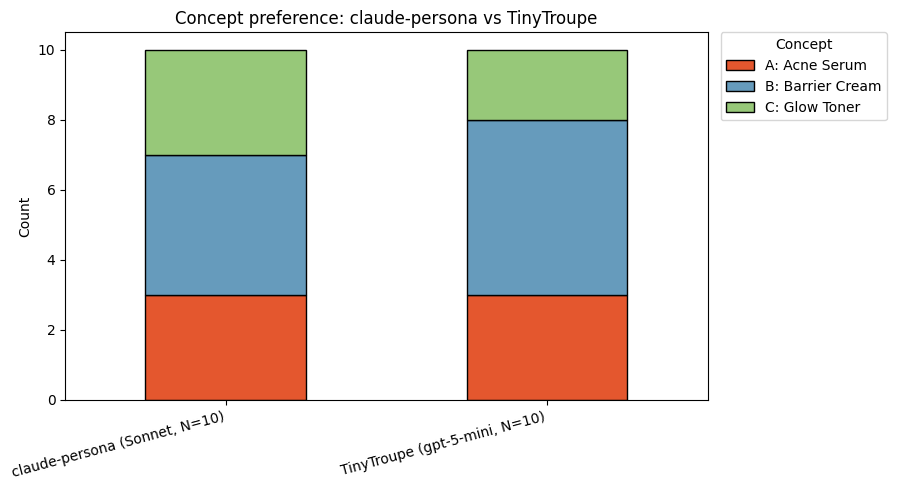


Mean purchase likelihood (raw, free-scale, this run): 7.30


In [10]:
summary = pd.DataFrame({
    'claude-persona (Sonnet, N=10)':   pd.Series({'A': 3, 'B': 4, 'C': 3}),
    'TinyTroupe (gpt-5-mini, N=10)':   counts,
})

print("Concept preference counts:\n")
display(summary)

shares = summary.div(summary.sum(axis=0), axis=1).round(2)
print("\nShare of panel:\n")
display(shares)

fig, ax = plt.subplots(figsize=(9, 5))
summary.T.plot(kind='bar', stacked=True, ax=ax,
               color=['#E4572E', '#669BBC', '#97C879'], edgecolor='black')
ax.set_title('Concept preference: claude-persona vs TinyTroupe')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(title='Concept', labels=['A: Acne Serum', 'B: Barrier Cream', 'C: Glow Toner'],
          bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

mean_pl = results_df['purchase_likelihood'].dropna().mean()
print(f"\nMean purchase likelihood (raw, free-scale, this run): {mean_pl:.2f}")


In [11]:
control.end()
